# Tensorflow模型优化

## 【章节目标】
- 了解过拟合和欠拟合概念
- 掌握早停，正则化技术
- 掌握 BN 层的使用
- 掌握 tensorflow 数据增强的方法
- ***注意：本章重复代码比较多，主要是对比优化结果***

## 【章节内容】
### 过拟合和欠拟合
模型的表达能力，也称之为模型的容量 (Capacity)。当模型的表达能力偏弱时，比如单层线性层，它只能学习到线性模型，无法良好地逼近非线性模型；但模型的表达能力过强时，他就有可能把训练集的噪声模态也学到，导致在测试机上面表现不佳的现象（泛化能力偏弱）。因此针对不同的任务，设计相应的模型算法才能取得较好的泛化性能。

#### 1）模型的容量
通俗的讲，模型的容量或表达能力，是指模型拟合复杂函数的能力。一种体现模型容量的指标为模型的假设空间 (Hypothesis Space) 大小，即模型可以表示的函数集的大小。假设空间越大越完备，从假设空间中搜索出逼近真实模型的函数也就越有可能；反之，如果假设空间非常受限，就很难从中找到逼近真实模型的函数。

但是过大的假设空间会增加搜索难度和计算代价，在有限的计算资源的约束下，较大的假设空间并不一定能搜索出更好的函数模型。同时由于观测误差的存在，较大的假设空间中可能包含了大量表达能力过强的函数，能够将训练样本的观测误差也学习进来，从而伤害了模型的泛化能力

**多项式模型容量示意图：**  
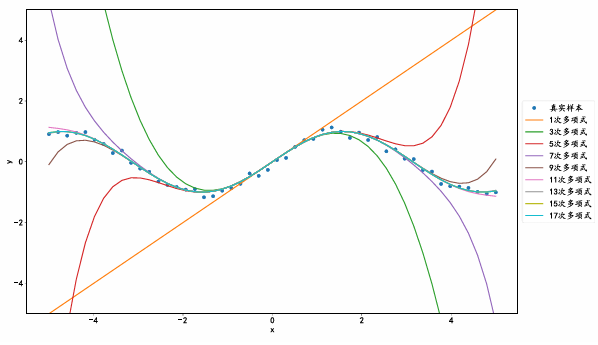

#### 2）过拟合与欠拟合
由于真实数据的分布往往是未知而且复杂的，无法推断出其分布函数的类型和相关参数，因此人们在选择模型的容量时，往往会根据经验值选择稍大的模型容量。但模型的容量过大时，有可能出现在训练样本上表现较好，但是测试样本上表现较差的现象，如图中红色竖线右边区域所示；当模型的容量过小时，有可能出现在训练样本和测试样本表现皆不佳的现象，如图中红色竖线左边区域所示。

**模型的容量和误差之间的关系：**  
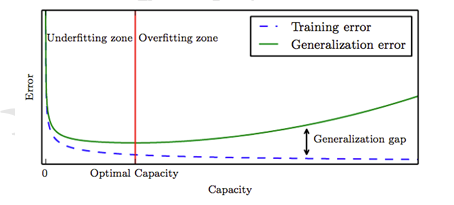

当模型的容量过大时，网络模型除了学习到训练集数据的模态之外，还把额外的观测误差也学习进来，导致学习的模型在训练集上表现较好，但是在未见的样本上表现不佳，也就是泛化能力偏弱，我们把这种现象叫做过拟合 (Overfitting)。  
当模型的容量过小时，模型不能够很好的学习到训练集数据的模态，导致训练集上表现不佳，同时在未见的样本上表现也不佳，我们把这种现象叫做欠拟合 (Underfitting)。

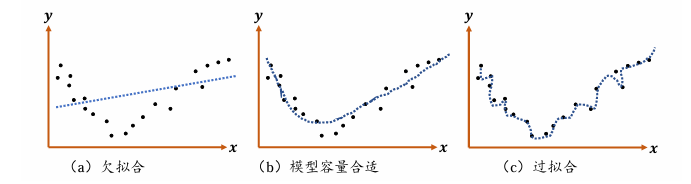

#### 3）模型设计
对于神经网络来说，网络的层数和参数量是网络容量很重要的参考指标，通过减少网络的层数、减少每层中网络参数量的规模可以有效降低网络的容量；
反之，如果发现模型欠拟合，需要增大网络的容量，可以通过增加层数、增大每层的参数量等方式实现。

网络层数：2 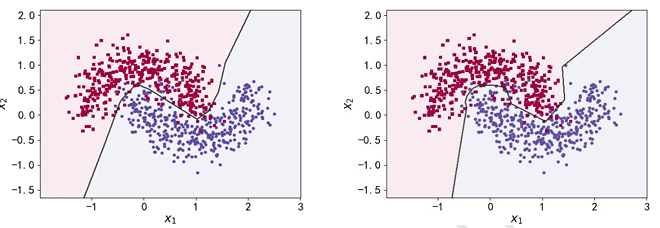 网络层数：3

网络层数：4 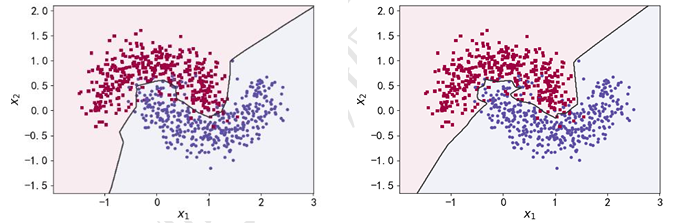 网络层数：6


#### 4）复杂模型实战 tf_flowers
针对 tf_flowers 任务，我们重新设计更为复杂的网络模型进行训练，下面使用搭建一个 7 层 CNN+3 层 FC 的网络为模型来进行训练。

##### 1. 构建数据集

In [2]:
import tensorflow as tf
import random
from datetime import datetime
import pathlib
random.seed(1)
data_path = pathlib.Path('Dataset/flower_photos/')
all_image_paths = list(data_path.glob('*/*'))
all_image_paths = [str(path) for path in all_image_paths] # 所有图片路径的列表
random.shuffle(all_image_paths)
label_names = sorted(item.name for item in data_path.glob('*/') if item.is_dir()) # 加载标签
label_to_index = dict((name, index) for index, name in enumerate(label_names)) # 构建标签字典
all_image_labels = [label_to_index[pathlib.Path(path).parent.name] for path in all_image_paths] # 标签id化

# 分割数据集
total_num = len(all_image_paths)
split_index = int(0.8*total_num)
train_x, train_y = all_image_paths[:split_index], all_image_labels[:split_index]
val_x, val_y = all_image_paths[split_index:], all_image_labels[split_index:]

# 构建数据集
train_db = tf.data.Dataset.from_tensor_slices((train_x, train_y))
val_db = tf.data.Dataset.from_tensor_slices((val_x, val_y))

# 定义预处理方法
def load_and_preprocess_from_path_label(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [128, 128])  # 原始图片大小为(266, 320, 3)，重设为(128, 128)
    image /= 255.0  # 归一化到[0,1]范围
    return image, label
train_db  = train_db.map(load_and_preprocess_from_path_label)
val_db  = val_db.map(load_and_preprocess_from_path_label)

#打乱并分批次
BATCH_SIZE = 32
train_db = train_db.shuffle(1000).batch(BATCH_SIZE).cache().prefetch(1000)
val_db = val_db.batch(BATCH_SIZE).cache().prefetch(1000)

2026-04-08 07:09:19.806636: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-08 07:09:19.806806: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-08 07:09:19.873843: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-08 07:09:23.687942: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.


##### 2. 搭建模型

In [3]:
num_classes=len(label_names)
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(num_classes)
])
model.build(input_shape = (None, 128, 128, 3)) # 初始化模型参数
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 124, 124, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2  (None, 62, 62, 32)        0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 58, 58, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 29, 29, 64)        0         
 g2D)                                                   

##### 3. 模型训练

In [ ]:
# 模型编译
log_dir = "log/keras_tf_flowers/" + datetime.now().strftime("%Y%m%d-%H%M%S")
# 创建回调
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir = log_dir, histogram_freq = 1)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(
    optimizer = optimizer,
    loss = tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ['accuracy']
)
model.fit(train_db, epochs=20,
          validation_data = val_db,
          callbacks = [tensorboard_callback])

Epoch 1/20


2026-04-07 19:10:51.075862: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 6291584000 bytes after encountering the first element of size 6291584 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1775589052.942256   41364 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 [==============================] - ETA: 0s - loss: 1.3369 - accuracy: 0.3978

2026-04-07 19:11:03.026608: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8388864000 bytes after encountering the first element of size 8388864 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-04-07 19:11:04.963223: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 4529848320 exceeds 10% of free system memory.


92/92 [==============================] - 18s 117ms/step - loss: 1.3369 - accuracy: 0.3978 - val_loss: 1.1406 - val_accuracy: 0.5163
Epoch 2/20
 2/92 [..............................] - ETA: 5s - loss: 1.1701 - accuracy: 0.3750

...

92/92 [==============================] - 7s 74ms/step - loss: 0.0455 - accuracy: 0.9877 - val_loss: 2.0836 - val_accuracy: 0.6267
Epoch 20/20
 3/92 [..............................] - ETA: 3s - loss: 0.0212 - accuracy: 1.0000

2026-04-07 19:13:05.270683: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 6291584000 bytes after encountering the first element of size 6291584 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


92/92 [==============================] - ETA: 0s - loss: 0.0237 - accuracy: 0.9959

2026-04-07 19:13:09.410228: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8388864000 bytes after encountering the first element of size 8388864 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


92/92 [==============================] - 7s 76ms/step - loss: 0.0237 - accuracy: 0.9959 - val_loss: 2.1917 - val_accuracy: 0.6226


#### 5）早停
对于神经网络，即使网络结构超参数保持不变（即网络最大容量固定），模型依然会出现过拟合的现象，这是因为神经网络的有效容量和训练的阶段相关，神经网络的有效容量可以很大，也可以通过稀疏化参数、添加正则化等手段降低。在训练的中期，神经网络学到一个较好的模型，使得过拟合现象出现，并且随着训练 epoch 数的增加，过拟合程度越来越严重。图中竖直虚线所处的网络状态最佳，没有出现明显的过拟合现象，网络的泛化能力最佳。

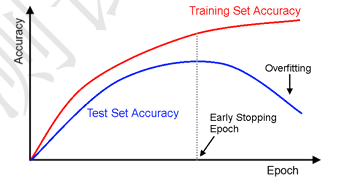

那么如何选择合适的 epoch 就停止训练（Early Stopping），避免出现过拟合现象呢？  

我们可以通过观察验证指标的变化，来预测最适合的 epoch 可能的位置。具体地，对于分类问题，我们可以记录模型的验证准确率，并监控验证准确率的变化，当发现验证准确率连续 P 个 Epoch 没有上升时，可以预测已经达到了最适合的 epoch 附近，从而提前终止训练。

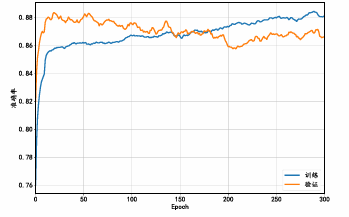

上图中绘制了某次具体的训练过程中训练和验证准确率随训练 epoch 的变化曲线，可以观察到，在 epoch 为 100 左右时，训练达到最优状态，此时可以提前终止训练。

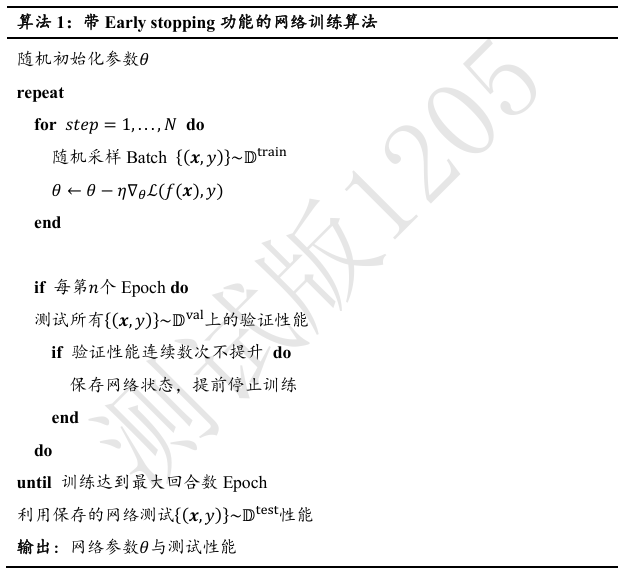

In [37]:
num_classes=len(label_names)
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(num_classes)
])
model.build(input_shape = (None, 128, 128, 3)) # 初始化模型参数
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 126, 126, 32)      896       
                                                                 
 conv2d_4 (Conv2D)           (None, 124, 124, 32)      9248      
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 62, 62, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 60, 60, 64)        18496     
                                                                 
 conv2d_6 (Conv2D)           (None, 58, 58, 64)        36928     
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 29, 29, 64)        0         
 g2D)                                                 

In [39]:
#定义统计损失的metrics
class EpochLoss(tf.keras.metrics.Metric):
    def __init__(self, name = 'EpochLoss', **kwargs):
        super(EpochLoss, self).__init__(name = name, **kwargs)
        self.total = self.add_weight(name = 'total', dtype = tf.float32, initializer = tf.zeros_initializer())
        self.count = self.add_weight(name = 'count', dtype = tf.float32, initializer = tf.zeros_initializer())

    def update_state(self, y_true, loss, sample_weight = None):
        #values = y_true.shape[0] * loss # 每个批次的样本数*平均损失
        # 改进：动态获取当前 batch 的真实样本数，并立刻转换为 float32
        batch_size = tf.cast(tf.shape(y_true)[0], tf.float32)
        loss = tf.cast(loss, tf.float32) # 确保 loss 也是 float32
        values = batch_size * loss
        self.total.assign_add(values) # 累加总损失值
        self.count.assign_add(y_true.shape[0]) # 累加总样本数
    
    def result(self):
        return self.total / self.count
    
    def reset_states(self):
        # The state of the metric will be reset at the start of each epoch.
        self.total.assign(0.0) # 总数归零
        self.count.assign(0.0) # 正确个数归零

In [40]:
# 1. 定义损失函数
loss_func = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
# 2. 先创建指数衰减学习率
exponential_decay = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-4,
    decay_steps=100,
    decay_rate=0.99
)
# 3. 送入优化器
optimizer = tf.keras.optimizers.Adam(exponential_decay)
# 4. 定义评估函数
acc = tf.keras.metrics.SparseCategoricalAccuracy()
# 5. 定义统计epoch平均损失的对象
eloss = EpochLoss()

In [41]:
def train_epoch(epoch):
    acc.reset_states()
    eloss.reset_states()
    for step, (x_batch_train, y_batch_train) in enumerate(train_db):
        # 开启gradient tape, 计算梯度
        with tf.GradientTape() as tape:
            predictions = model(x_batch_train, training = True) # 计算输出值
            loss = loss_func(y_batch_train, predictions) # 计算损失值
        gradients = tape.gradient(loss, model.trainable_variables) # 计算梯度值
        optimizer.apply_gradients(zip(gradients, model.trainable_variables)) # 优化更新参数
        eloss.update_state(y_batch_train, loss)
        acc.update_state(y_batch_train, predictions)
    print('epoch %s---Training loss : %s---Training acc : %s' % (epoch,
                                                                 eloss.result().numpy(),
                                                                 acc.result().numpy()))
    
def test_epoch(epoch):
    acc.reset_states()
    eloss.reset_states()
    for x_batch_val, y_batch_val in val_db: # 不需要求梯度
        predictions = model(x_batch_val, training = False) # 计算输出图
        loss = loss_func(y_batch_val, predictions)
        eloss.update_state(y_batch_val, loss)
        acc.update_state(y_batch_val, predictions)
    print('epoch %s---val loss : %s---val acc : %s' % (epoch,
                                                       eloss.result().numpy(),
                                                       acc.result().numpy()))
    return acc.result().numpy()

# 早停实现
def train(val_internal = 2, patient = 3, epochs = 1000):
    best_acc = 0.0
    patient_count = 0
    for epoch in range(1, epochs):
        train_epoch(epoch)
        if epoch % val_internal == 0:
            val_acc = test_epoch(epoch)
            if val_acc>best_acc:
                best_acc = val_acc # 保存最好成绩
                patient_count = 0 # 累计数归零
            elif patient_count<patient:
                patient_count += 1 # 未到次数，次数加1
            else:
                print(f"训练结束，迭代{epoch - val_internal * (patient_count+1)}轮，最优成绩{best_acc}") # 达到次数，停止训练
                break

train()

2026-04-07 20:42:10.017680: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 6291584000 bytes after encountering the first element of size 6291584 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


epoch 1---Training loss : 1.3671112---Training acc : 0.3906676


2026-04-07 20:42:22.617705: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 6291584000 bytes after encountering the first element of size 6291584 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


epoch 2---Training loss : 1.1097416---Training acc : 0.5487057


2026-04-07 20:42:27.158846: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 6291712000 bytes after encountering the first element of size 6291712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


...

epoch 15---Training loss : 0.12228296---Training acc : 0.96525884


2026-04-07 20:43:31.341495: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 6291584000 bytes after encountering the first element of size 6291584 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


epoch 16---Training loss : 0.08465853---Training acc : 0.97888285


2026-04-07 20:43:35.870800: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 6291712000 bytes after encountering the first element of size 6291712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


epoch 16---val loss : 1.8504823---val acc : 0.5871935
训练结束，迭代8轮，最优成绩0.6335150003433228


### 正则化
#### 1）正则化简介
通过设计不同层数、大小的网络模型可以为优化算法提供初始的函数假设空间，但是模型的实际容量可以随着网络参数的优化更新而产生变化。通过正则化限制网络参数的稀疏性，可以来约束网络的实际容量。

常用的正则化方式有 L0,L1,L2 正则化，以及dropout模型正则化。

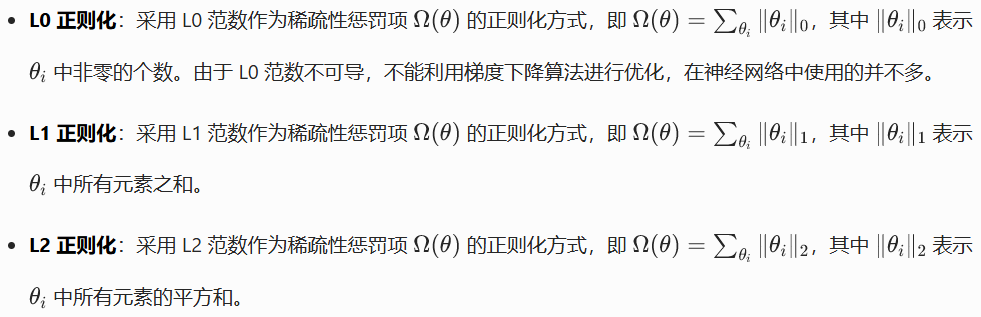

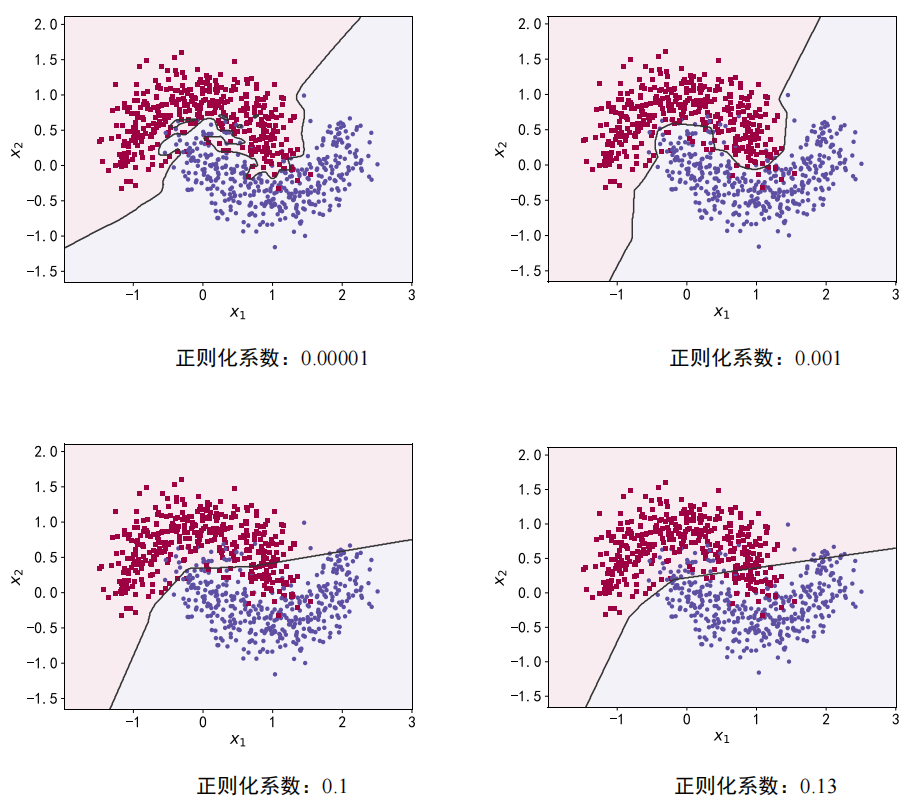

- Dropout：Dropout 通过随机断开神经网络的连接，减少每次训练时实际参与计算的模型的参数量；但是在测试时，Dropout 会恢复所有的连接，保证模型测试时获得最好的性能。

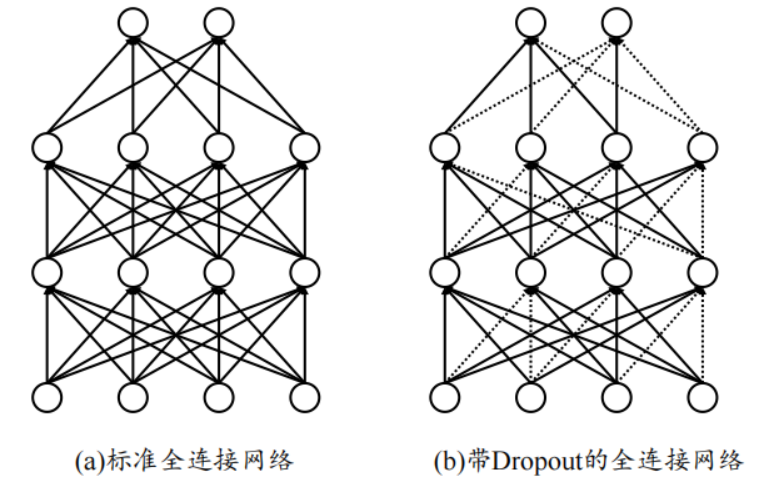

#### 2）tesnorflow中使用L1、L2正则
tf.keras.regularizers 提供了几种内置类来提供正则。分别是 class L1、class L1L2、class L2、class Regularizer 、serialize。同时提供了三个参数作为可被正则化的对象：

- kernel_regularizer:对该层中的权值矩阵layer.weights正则
- bias_regularizer:对该层中的偏差矩阵layer.bias正则
- activity_regularizer:对该层的输出值矩阵layer.output正则

使用示例：dense = tf.keras.layers.Dense(3, kernel_regularizer='l1') 

注意，keras和自定义训练计算正则损失的方式不同：

- keras：model.complie()时自动将模型损失和正则损失加入model.losses
- 自定义训练添加正则：  
reg_losses = tf.reduce_sum(model.losses) # 计算正则损失，model.losses保存的类似上面那个示例Dense参数注册的l1  
loss = loss_func(y_batch_train, predictions) + reg_losses # 计算总损失值 = 任务损失 + 正则损失

**tensorflow 正则化实战**

In [3]:
weight_decay = 0.001
num_classes=len(label_names)
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Conv2D(32, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Conv2D(64, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Conv2D(64, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Dense(num_classes, kernel_regularizer=tf.keras.regularizers.l2(weight_decay))
])
model.build(input_shape = (None, 128, 128, 3)) # 初始化模型参数
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 124, 124, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2  (None, 62, 62, 32)        0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 58, 58, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 29, 29, 64)        0         
 g2D)                                                   

In [4]:
# 模型编译
log_dir = "log/keras_tf_flowers/" + datetime.now().strftime("%Y%m%d-%H%M%S")
# 创建回调
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir = log_dir, histogram_freq = 1)
estop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=0)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(
    optimizer = optimizer,
    loss = tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ['accuracy']
)
model.fit(train_db, epochs=100,
          validation_data = val_db,
          callbacks = [tensorboard_callback, estop])

Epoch 1/100


I0000 00:00:1775632469.307569    4883 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 [==============================] - ETA: 0s - loss: 3.3486 - accuracy: 0.3934

2026-04-08 07:14:39.143620: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8388864000 bytes after encountering the first element of size 8388864 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-04-08 07:14:40.912808: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 2264924160 exceeds 10% of free system memory.


92/92 [==============================] - 17s 100ms/step - loss: 3.3486 - accuracy: 0.3934 - val_loss: 2.9071 - val_accuracy: 0.4373
Epoch 2/100
 3/92 [..............................] - ETA: 4s - loss: 2.8766 - accuracy: 0.4375

...

92/92 [==============================] - 6s 61ms/step - loss: 0.9320 - accuracy: 0.8944 - val_loss: 2.1179 - val_accuracy: 0.5926
Epoch 18/100
 4/92 [>.............................] - ETA: 4s - loss: 1.0392 - accuracy: 0.8281

2026-04-08 07:16:14.075679: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 6291584000 bytes after encountering the first element of size 6291584 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


91/92 [============================>.] - ETA: 0s - loss: 0.9035 - accuracy: 0.9107

2026-04-08 07:16:18.309296: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8388864000 bytes after encountering the first element of size 8388864 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


92/92 [==============================] - 6s 63ms/step - loss: 0.9040 - accuracy: 0.9101 - val_loss: 2.2162 - val_accuracy: 0.5954


**自定义训练**

In [5]:
weight_decay = 0.001
num_classes=len(label_names)
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Conv2D(32, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Conv2D(64, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Conv2D(64, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Dense(num_classes, kernel_regularizer=tf.keras.regularizers.l2(weight_decay))
])
model.build(input_shape = (None, 128, 128, 3)) # 初始化模型参数
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 126, 126, 32)      896       
                                                                 
 conv2d_7 (Conv2D)           (None, 124, 124, 32)      9248      
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 62, 62, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_8 (Conv2D)           (None, 60, 60, 64)        18496     
                                                                 
 conv2d_9 (Conv2D)           (None, 58, 58, 64)        36928     
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 29, 29, 64)        0         
 g2D)                                                 

In [6]:
#定义统计损失的metrics
class EpochLoss(tf.keras.metrics.Metric):
    def __init__(self, name = 'EpochLoss', **kwargs):
        super(EpochLoss, self).__init__(name = name, **kwargs)
        self.total = self.add_weight(name = 'total', dtype = tf.float32, initializer = tf.zeros_initializer())
        self.count = self.add_weight(name = 'count', dtype = tf.float32, initializer = tf.zeros_initializer())

    def update_state(self, y_true, loss, sample_weight = None):
        #values = y_true.shape[0] * loss # 每个批次的样本数*平均损失
        # 改进：动态获取当前 batch 的真实样本数，并立刻转换为 float32
        batch_size = tf.cast(tf.shape(y_true)[0], tf.float32)
        loss = tf.cast(loss, tf.float32) # 确保 loss 也是 float32
        values = batch_size * loss
        self.total.assign_add(values) # 累加总损失值
        self.count.assign_add(y_true.shape[0]) # 累加总样本数
    
    def result(self):
        return self.total / self.count
    
    def reset_states(self):
        # The state of the metric will be reset at the start of each epoch.
        self.total.assign(0.0) # 总数归零
        self.count.assign(0.0) # 正确个数归零

In [7]:
# 1. 定义损失函数
loss_func = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
# 2. 先创建指数衰减学习率
exponential_decay = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-4,
    decay_steps=100,
    decay_rate=0.99
)
# 3. 送入优化器
optimizer = tf.keras.optimizers.Adam(exponential_decay)
# 4. 定义评估函数
acc = tf.keras.metrics.SparseCategoricalAccuracy()
# 5. 定义统计epoch平均损失的对象
eloss = EpochLoss()

In [8]:
def train_epoch(epoch):
    acc.reset_states()
    eloss.reset_states()
    for step, (x_batch_train, y_batch_train) in enumerate(train_db):
        # 开启gradient tape, 计算梯度
        with tf.GradientTape() as tape:
            predictions = model(x_batch_train, training = True) # 计算输出值
            ###增加
            reg_losses = tf.reduce_sum(model.losses) # 计算正则损失
            ###
            loss = loss_func(y_batch_train, predictions) + reg_losses # 计算损失值
        gradients = tape.gradient(loss, model.trainable_variables) # 计算梯度值
        optimizer.apply_gradients(zip(gradients, model.trainable_variables)) # 优化更新参数
        eloss.update_state(y_batch_train, loss)
        acc.update_state(y_batch_train, predictions)
    print('epoch %s---Training loss : %s---Training acc : %s' % (epoch,
                                                                 eloss.result().numpy(),
                                                                 acc.result().numpy()))
    
def test_epoch(epoch):
    acc.reset_states()
    eloss.reset_states()
    for x_batch_val, y_batch_val in val_db: # 不需要求梯度
        predictions = model(x_batch_val, training = False) # 计算输出图
        loss = loss_func(y_batch_val, predictions)
        eloss.update_state(y_batch_val, loss)
        acc.update_state(y_batch_val, predictions)
    print('epoch %s---val loss : %s---val acc : %s' % (epoch,
                                                       eloss.result().numpy(),
                                                       acc.result().numpy()))
    return acc.result().numpy()

# 早停实现
def train(val_internal = 2, patient = 3, epochs = 1000):
    best_acc = 0.0
    patient_count = 0
    for epoch in range(1, epochs):
        train_epoch(epoch)
        if epoch % val_internal == 0:
            val_acc = test_epoch(epoch)
            if val_acc>best_acc:
                best_acc = val_acc # 保存最好成绩
                patient_count = 0 # 累计数归零
            elif patient_count<patient:
                patient_count += 1 # 未到次数，次数加1
            else:
                print(f"训练结束，迭代{epoch - val_internal * (patient_count+1)}轮，最优成绩{best_acc}") # 达到次数，停止训练
                break

train()

2026-04-08 07:24:25.248335: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 6291584000 bytes after encountering the first element of size 6291584 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


epoch 1---Training loss : 3.3229954---Training acc : 0.373297


2026-04-08 07:24:36.748127: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 6291584000 bytes after encountering the first element of size 6291584 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


epoch 2---Training loss : 2.4455812---Training acc : 0.508515


2026-04-08 07:24:43.820439: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8388864000 bytes after encountering the first element of size 8388864 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


...

epoch 19---Training loss : 0.8929923---Training acc : 0.8858992


2026-04-08 07:26:56.929926: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 6291584000 bytes after encountering the first element of size 6291584 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


epoch 20---Training loss : 0.89024556---Training acc : 0.8797684


2026-04-08 07:27:04.256955: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8388864000 bytes after encountering the first element of size 8388864 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


epoch 20---val loss : 1.6118275---val acc : 0.56948227
训练结束，迭代12轮，最优成绩0.6212534308433533


#### 3）tensorflow 中使用 Dropout
tensorflow 中实现 Dropout 是由层 tf.keras.layers.Dropout(rate) 实现：
- rate：将数据变成 0 的概率

**注意：Dropout 在训练时神经元输出随机变为 0，但在测试时所有神经元都工作，因此训练过程和测试过程不一致，在自定义训练时需要做以下设置(前面也已经考虑了)：**

- 训练时：pred=model(data, training=True)
- 测试时：pred=model(data, training=False)

**Dropout实战**

In [9]:
weight_decay = 0.001
num_classes=len(label_names)
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Conv2D(32, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Conv2D(64, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Conv2D(64, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, kernel_regularizer=tf.keras.regularizers.l2(weight_decay))
])
model.build(input_shape = (None, 128, 128, 3)) # 初始化模型参数
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 126, 126, 32)      896       
                                                                 
 conv2d_13 (Conv2D)          (None, 124, 124, 32)      9248      
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 62, 62, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_14 (Conv2D)          (None, 60, 60, 64)        18496     
                                                                 
 conv2d_15 (Conv2D)          (None, 58, 58, 64)        36928     
                                                                 
 max_pooling2d_7 (MaxPoolin  (None, 29, 29, 64)        0         
 g2D)                                                 

**keras训练**

In [10]:
estop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=0)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(
    optimizer = optimizer,
    loss = tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ['accuracy']
)
model.fit(train_db, epochs=200,
          validation_data = val_db,
          callbacks = [estop])

Epoch 1/200


2026-04-08 07:36:55.606017: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 6291584000 bytes after encountering the first element of size 6291584 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


91/92 [============================>.] - ETA: 0s - loss: 3.4745 - accuracy: 0.3396

2026-04-08 07:37:01.307521: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8388864000 bytes after encountering the first element of size 8388864 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


92/92 [==============================] - 7s 44ms/step - loss: 3.4688 - accuracy: 0.3413 - val_loss: 2.8756 - val_accuracy: 0.4564
Epoch 2/200
 5/92 [>.............................] - ETA: 3s - loss: 2.8872 - accuracy: 0.4125

...

92/92 [==============================] - 4s 43ms/step - loss: 0.9721 - accuracy: 0.8375 - val_loss: 1.4045 - val_accuracy: 0.7044
Epoch 24/200
 5/92 [>.............................] - ETA: 3s - loss: 1.0152 - accuracy: 0.8438

2026-04-08 07:38:30.092308: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 6291584000 bytes after encountering the first element of size 6291584 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


91/92 [============================>.] - ETA: 0s - loss: 0.9321 - accuracy: 0.8530

2026-04-08 07:38:33.861502: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8388864000 bytes after encountering the first element of size 8388864 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


92/92 [==============================] - 4s 44ms/step - loss: 0.9305 - accuracy: 0.8542 - val_loss: 1.4801 - val_accuracy: 0.7044


**自定义训练**

In [11]:
weight_decay = 0.001
num_classes=len(label_names)
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Conv2D(32, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Conv2D(64, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Conv2D(64, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(num_classes, kernel_regularizer=tf.keras.regularizers.l2(weight_decay))
])
model.build(input_shape = (None, 128, 128, 3)) # 初始化模型参数
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_18 (Conv2D)          (None, 126, 126, 32)      896       
                                                                 
 conv2d_19 (Conv2D)          (None, 124, 124, 32)      9248      
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 62, 62, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_20 (Conv2D)          (None, 60, 60, 64)        18496     
                                                                 
 conv2d_21 (Conv2D)          (None, 58, 58, 64)        36928     
                                                                 
 max_pooling2d_10 (MaxPooli  (None, 29, 29, 64)        0         
 ng2D)                                                

In [12]:
# 1. 定义损失函数
loss_func = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
# 2. 先创建指数衰减学习率
exponential_decay = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-4,
    decay_steps=100,
    decay_rate=0.99
)
# 3. 送入优化器
optimizer = tf.keras.optimizers.Adam(exponential_decay)
# 4. 定义评估函数
acc = tf.keras.metrics.SparseCategoricalAccuracy()
# 5. 定义统计epoch平均损失的对象
eloss = EpochLoss()

In [13]:
def train_epoch(epoch):
    acc.reset_states()
    eloss.reset_states()
    for step, (x_batch_train, y_batch_train) in enumerate(train_db):
        # 开启gradient tape, 计算梯度
        with tf.GradientTape() as tape:
            predictions = model(x_batch_train, training = True) # 计算输出值
            ###增加
            reg_losses = tf.reduce_sum(model.losses) # 计算正则损失
            ###
            loss = loss_func(y_batch_train, predictions) + reg_losses # 计算损失值
        gradients = tape.gradient(loss, model.trainable_variables) # 计算梯度值
        optimizer.apply_gradients(zip(gradients, model.trainable_variables)) # 优化更新参数
        eloss.update_state(y_batch_train, loss)
        acc.update_state(y_batch_train, predictions)
    print('epoch %s---Training loss : %s---Training acc : %s' % (epoch,
                                                                 eloss.result().numpy(),
                                                                 acc.result().numpy()))
    
def test_epoch(epoch):
    acc.reset_states()
    eloss.reset_states()
    for x_batch_val, y_batch_val in val_db: # 不需要求梯度
        predictions = model(x_batch_val, training = False) # 计算输出图
        loss = loss_func(y_batch_val, predictions)
        eloss.update_state(y_batch_val, loss)
        acc.update_state(y_batch_val, predictions)
    print('epoch %s---val loss : %s---val acc : %s' % (epoch,
                                                       eloss.result().numpy(),
                                                       acc.result().numpy()))
    return acc.result().numpy()

# 早停实现
def train(val_internal = 2, patient = 3, epochs = 1000):
    best_acc = 0.0
    patient_count = 0
    for epoch in range(1, epochs):
        train_epoch(epoch)
        if epoch % val_internal == 0:
            val_acc = test_epoch(epoch)
            if val_acc>best_acc:
                best_acc = val_acc # 保存最好成绩
                patient_count = 0 # 累计数归零
            elif patient_count<patient:
                patient_count += 1 # 未到次数，次数加1
            else:
                print(f"训练结束，迭代{epoch - val_internal * (patient_count+1)}轮，最优成绩{best_acc}") # 达到次数，停止训练
                break

train()

2026-04-08 07:42:47.106023: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 6291584000 bytes after encountering the first element of size 6291584 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


epoch 1---Training loss : 3.3966107---Training acc : 0.34809265


2026-04-08 07:42:55.217885: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 6291584000 bytes after encountering the first element of size 6291584 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


epoch 2---Training loss : 2.5356398---Training acc : 0.48092642


2026-04-08 07:43:01.695974: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8388864000 bytes after encountering the first element of size 8388864 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


...

epoch 23---Training loss : 0.771517---Training acc : 0.9322207


2026-04-08 07:45:40.465287: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 6291584000 bytes after encountering the first element of size 6291584 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


epoch 24---Training loss : 0.70249295---Training acc : 0.9550409


2026-04-08 07:45:47.841775: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8388864000 bytes after encountering the first element of size 8388864 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


epoch 24---val loss : 1.6045494---val acc : 0.6294278
训练结束，迭代16轮，最优成绩0.664850115776062


### tensorflow 中的权值初始化
#### 1）初始化器的概念及其用法
概念:初始化定义了设置 Keras 各层权重随机初始值的方法。

用法:用来将初始化器传入 Keras 层（包括不限于 Dense 层、Conv2D 层、等等）的参数名取决于具体的层。通常关键字为 kernel_initializer 和 bias_initializer：
- 方式 1：传递初始化器名字字符串  
model.add(Dense(64, kernel_initializer='random_uniform', bias_initializer='zeros'))

- 方式 2：传递初始化器实例  
model.add(Dense(64,
    kernel_initializer=keras.initializers.Constant(value=3.0),
    bias_initializer=keras.initializers.RandomNormal(mean=0.0, stddev=0.05, seed=None)
))

**提示（默认值）**

- kernel_initializer 默认值为 glorot_uniform，对应的实例是 tf.keras.initializers.GlorotUniform(seed=None)
- bias_initializer 默认值为 zeros，对应的实例是 tf.keras.initializers.Zeros()

#### 2）可用的初始化器
tensorflow 提供的权值初始化工具都在 tf.keras.initializers 中:

- tf.keras.initializers.Initializer () #初始化器基类：所有初始化器继承这个类。
- tf.keras.initializers.Zeros () #将张量初始值设为 0 的初始化器。
- tf.keras.initializers.Ones () #将张量初始值设为 1 的初始化器。将张量初始值设为 1 的初始化器。将张量初始值设为 1 的初始化器。
- tf.keras.initializers.Constant (value=0) #将张量初始值设为一个常数的初始化器。value: 浮点数，生成的张量的值。
- tf.keras.initializers.RandomNormal (mean=0.0, stddev=0.05, seed=None) #按照正态分布生成随机张量的初始化器。
- tf.keras.initializers.RandomUniform (minval=-0.05, maxval=0.05, seed=None) #按照均匀分布生成随机张量的初始化器。
- tf.keras.initializers.TruncatedNormal (mean=0.0, stddev=0.05, seed=None) #按照截尾正态分布生成随机张量的初始化器。
- tf.keras.initializers.VarianceScaling (scale=1.0, mode='fan_in', distribution='normal', seed=None) #初始化器能够根据权值的尺寸调整其规模。
- tf.keras.initializers.Orthogonal (gain=1.0, seed=None) #生成一个随机正交矩阵的初始化器。
- tf.keras.initializers.Identity (gain=1.0) #生成单位矩阵的初始化器。
- tf.keras.initializers.LecunUniform (seed=None) #LeCun 均匀初始化器。
- tf.keras.initializers.LecunNormal (seed=None) #LeCun 正态分布初始化器。
- tf.keras.initializers.GlorotNormal (seed=None) #Glorot 正态分布初始化器
- tf.keras.initializers.GlorotUniform (seed=None) #Glorot 均匀分布初始化器，也称为 Xavier 均匀分布初始化器。
- tf.keras.initializers.HeNormal (seed=None) #He 正态分布初始化器。
- tf.keras.initializers.HeUniform (seed=None) #He 均匀方差缩放初始化器。

提示:

初始化器对应的名字字符串为类名的小写，例如初始化器 tf.keras.initializers.RandomNormal (mean=0.0, stddev=0.05, seed=None) 的名字字符串就是 'randomnormal'

#### 3）使用自定义初始化器

如果传递一个自定义的可调用函数，那么它必须使用参数 shape（需要初始化的变量的尺寸）和 dtype（数据类型）：

In [ ]:
def my_init(shape, dtype = None):
    return tf.random.normal(shape, dtype=dtype)

model.add(tf.keras.layers.Dense(64, kernel_initializer=my_init))

### tensorflow中使用batchnormalization
#### 1）BN的作用

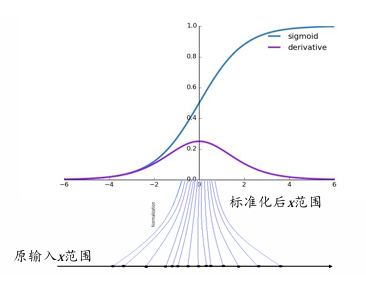

从比较图可以看出，Sigmoid 函数在 [-2, 2] 区间导数值在 [0.1, 0.25]，当输入大于 2 或者小于 2 时，导数逼近 0，从而容易出现梯度消失的现象。Tanh 函数在输入值经过变换后，输入值被映射在 0 附近区域，此处的导数不会太小，不会容易出现梯度弥散的现象。

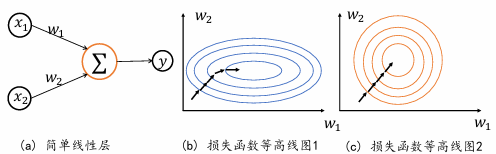

如上图所示的损失函数等高线图可知，当x1​和x2​分布相近时，收敛更加快速，优化轨迹更好。
结论：通过标准化后，输入值被映射在 0 附近区域，此处的导数不会太小，不会容易出现梯度弥散的现象；网络层输入分布相近，收敛速度更快。

#### 2）如何保证输入的分布相近

$$\mu_B = \frac{1}{m} \sum_{i=1}^m x_i$$
$$\sigma_B^2 = \frac{1}{m} \sum_{i=1}^m (x_i - \mu_B)^2$$
$$\hat{x}_{\text{train}} = \frac{x_{\text{train}} - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$

其中，m 为 Batch 样本数，Batch 内部的均值和方差分别为 μB​ 和 σB^2​，μB​ 和 σB^2 是通过训练数据统计出来的。  
ϵ 是为了防止出现除 0 的错误而设置的较小的数，例如 1e−8。为了提高 BN 层的表达能力，引入了缩放和平移。  
参数 γ 和 β 由反向传播算法自动优化，实现网络层按需要缩放和平移数据的分布的目的。  

#### 3）tensorflow2.X 中的实现

在 TensorFlow 中，通过 tf.keras.layers.BatchNormalization() 类可以非常方便地实现 BN 层：

    layer = tf.keras.layers.BatchNormalization()

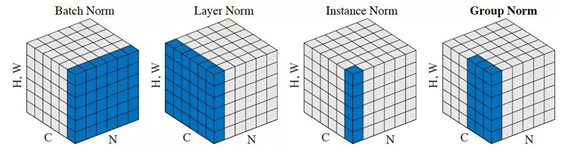

- tf.keras.layers.BatchNormalization：由于 BN 在训练和测试过程的行为不同，需要通过设置 training 标志来区分。训练时加上 training=True，测试时加上 training=False（类似 Dropout）。
- tf.keras.layers.LayerNormalization：统计每个样本的所有特征的均值和方差，不需要 training=True。

#### 4）BatchNormalization 实践案例
BN 层提出后便广泛地应用在各种深度网络模型上，卷积层、BN 层、ReLU 层、池化层一度成为网络模型的标配单元块，通过堆叠 Conv-BN-ReLU-Pooling 方式往往可以获得不错的模型性能。

**我们使用 BatchNormalization 来改进 tfflowers 模型**

In [14]:
num_classes=len(label_names)
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Conv2D(32, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(num_classes)
])
model.build(input_shape = (None, 128, 128, 3)) # 初始化模型参数
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_24 (Conv2D)          (None, 128, 128, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 128, 128, 32)      128       
 Normalization)                                                  
                                                                 
 re_lu (ReLU)                (None, 128, 128, 32)      0         
                                                                 
 conv2d_25 (Conv2D)          (None, 128, 128, 32)      9248      
                                                                 
 batch_normalization_1 (Bat  (None, 128, 128, 32)      128       
 chNormalization)                                                
                                                                 
 re_lu_1 (ReLU)              (None, 128, 128, 32)     

In [15]:
estop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=0)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(
    optimizer = optimizer,
    loss = tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ['accuracy']
)
model.fit(train_db, epochs=200,
          validation_data = val_db,
          callbacks = [estop])

Epoch 1/200


2026-04-08 08:51:53.612239: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 6291584000 bytes after encountering the first element of size 6291584 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


92/92 [==============================] - ETA: 0s - loss: 1.5736 - accuracy: 0.4196

2026-04-08 08:52:12.375830: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8388864000 bytes after encountering the first element of size 8388864 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


92/92 [==============================] - 22s 146ms/step - loss: 1.5736 - accuracy: 0.4196 - val_loss: 1.7889 - val_accuracy: 0.2493
Epoch 2/200
 3/92 [..............................] - ETA: 5s - loss: 1.1326 - accuracy: 0.5729

...

92/92 [==============================] - 5s 58ms/step - loss: 0.2276 - accuracy: 0.9172 - val_loss: 1.5672 - val_accuracy: 0.6172
Epoch 12/200
 3/92 [..............................] - ETA: 4s - loss: 0.3167 - accuracy: 0.9167

2026-04-08 08:53:13.948663: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 6291584000 bytes after encountering the first element of size 6291584 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


91/92 [============================>.] - ETA: 0s - loss: 0.2253 - accuracy: 0.9241

2026-04-08 08:53:19.137684: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8388864000 bytes after encountering the first element of size 8388864 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


92/92 [==============================] - 6s 61ms/step - loss: 0.2244 - accuracy: 0.9244 - val_loss: 2.5595 - val_accuracy: 0.5599


由于数据量比较小，验证集上最终的效果也很难超过之前只用dropout的方式是，由此引出接下来内容

### 数据增强
tensorflow2 的在线数据增强方法有三种:
- 1. 在 tf.data 的 map 过程使用 tf.image
- 2. 使用 tf.keras 的预处理层 tf.keras.layers.experimental.preprocessing
- 3. 使用 keras.preprocessing.image.ImageDataGenerator
#### 1) tf.image
- tf.image.flip_left_right、tf.image.random_flip_left_right：左右翻转
- tf.image.flip_up_down、tf.image.random_flip_up_down：上下翻转
- tf.image.rgb_to_grayscale：转灰度
- tf.image.adjust_brightness、tf.image.random_brightness：调整亮度
- tf.image.adjust_saturation、tf.image.random_saturation：调整饱和度
- tf.image.adjust_gamma：调整曲线
- tf.image.adjust_contrast、tf.image.random_contrast：调整对比度
- tf.image.adjust_hue、tf.image.random_hue：调整色调
- tf.image.rot90：将 image 图像逆时针旋转 90 度。
- tf.image.crop_and_resize：裁剪并 resize
- tf.image.central_crop：中心裁剪
- tf.image.random_crop：随机裁剪
- tf.image.resize：变换尺寸
- tf.image.convert_image_dtype：将一个 uint 类型的 tensor 转换为 float 类型时，该方法会自动对数据进行归一化处理，将数据缩放到 0-1 范围内，如果没有注意到这点，之后在进行网络训练时会发现网络不收敛、不训练。

使用方法：定义一个 preprocess 函数（对图像进行预处理，对图像进行增强），并在 datasets 的 map 方法中执行该函数

**tfflowers实战案例**

In [16]:
#构建数据集
import tensorflow as tf
import random
from datetime import datetime
import pathlib
random.seed(1)
data_path = pathlib.Path('Dataset/flower_photos/')
all_image_paths = list(data_path.glob('*/*'))
all_image_paths = [str(path) for path in all_image_paths] # 所有图片路径的列表
random.shuffle(all_image_paths)
label_names = sorted(item.name for item in data_path.glob('*/') if item.is_dir()) # 加载标签
label_to_index = dict((name, index) for index, name in enumerate(label_names)) # 构建标签字典
all_image_labels = [label_to_index[pathlib.Path(path).parent.name] for path in all_image_paths] # 标签id化

# 分割数据集
total_num = len(all_image_paths)
split_index = int(0.8*total_num)
train_x, train_y = all_image_paths[:split_index], all_image_labels[:split_index]
val_x, val_y = all_image_paths[split_index:], all_image_labels[split_index:]

# 构建数据集
train_db = tf.data.Dataset.from_tensor_slices((train_x, train_y))
val_db = tf.data.Dataset.from_tensor_slices((val_x, val_y))

In [17]:
#训练集做数据增强，验证集和测试集不用
#定义预处理方法
def load_and_preprocess_from_path_label_train(path, label):
    image = tf.io.read_file(path) # 读取图片
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.cast(image, tf.float32) #不能用tf.image.convert_image_dtype
    image = tf.image.resize(image, [142, 142])
    image = tf.image.random_crop(image, size=[128, 128, 3]) # 随机裁剪成128*128大小
    image = tf.image.random_brightness(image, max_delta=0.3) # 随机增加亮度
    # image = tf.image.random_saturation(image, 0.5) # 随机改变色调
    image = tf.image.random_flip_left_right(image) # 随机左右翻转
    # image = tf.image.random_flip_up_down(image) # 随机上下翻转
    image = tf.clip_by_value(image, 0, 255)
    image /= 128.0 # 归一化到[0, 2]范围
    image -= 1.0 # 归一化到[-1, 1]范围
    return image, label

def load_and_preprocess_from_path_label(path, label):
    image = tf.io.read_file(path) # 读取图片
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [128, 128])

    image /= 128.0 # 归一化到[0, 2]范围
    image -= 1.0 # 归一化到[-1, 1]范围
    return image, label

In [18]:
AUTOTUNE = tf.data.AUTOTUNE # 定义自适应预取

no_augument_train_db = train_db.map(load_and_preprocess_from_path_label, num_parallel_calls=AUTOTUNE)
augument_train_db = train_db.map(load_and_preprocess_from_path_label_train, num_parallel_calls=AUTOTUNE)
val_db = val_db.map(load_and_preprocess_from_path_label, num_parallel_calls=AUTOTUNE)

#打乱并分批，这里顺便更正一下cache使用的顺序，放后面会让前面一系列打乱失效，prefetch也不要一次写这么多
BATCH_SIZE = 32
# 无增强训练集：可以 cache，但顺序必须是 cache -> shuffle -> batch -> prefetch
no_augument_train_db = no_augument_train_db.cache().shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
# 有增强训练集：不要 cache！直接 shuffle -> batch -> prefetch
augument_train_db = augument_train_db.shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
# 验证集：不需要 shuffle，先 cache -> batch -> prefetch
val_db = val_db.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [19]:
num_classes=len(label_names)
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Conv2D(32, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(num_classes)
])
model.build(input_shape = (None, 128, 128, 3)) # 初始化模型参数
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_30 (Conv2D)          (None, 128, 128, 32)      896       
                                                                 
 batch_normalization_6 (Bat  (None, 128, 128, 32)      128       
 chNormalization)                                                
                                                                 
 re_lu_6 (ReLU)              (None, 128, 128, 32)      0         
                                                                 
 conv2d_31 (Conv2D)          (None, 128, 128, 32)      9248      
                                                                 
 batch_normalization_7 (Bat  (None, 128, 128, 32)      128       
 chNormalization)                                                
                                                                 
 re_lu_7 (ReLU)              (None, 128, 128, 32)     

**没有使用数据增强训练**

In [20]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer,
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
model.fit(no_augument_train_db, epochs=40,
          validation_data=val_db)

Epoch 1/40
92/92 [==============================] - 12s 67ms/step - loss: 1.5246 - accuracy: 0.4278 - val_loss: 1.6512 - val_accuracy: 0.2507
Epoch 2/40
92/92 [==============================] - 5s 59ms/step - loss: 1.1361 - accuracy: 0.5364 - val_loss: 1.8234 - val_accuracy: 0.2752
Epoch 3/40
92/92 [==============================] - 5s 60ms/step - loss: 1.0479 - accuracy: 0.5834 - val_loss: 1.6035 - val_accuracy: 0.3420
Epoch 4/40
92/92 [==============================] - 6s 60ms/step - loss: 0.8934 - accuracy: 0.6427 - val_loss: 1.0436 - val_accuracy: 0.5640
Epoch 5/40
92/92 [==============================] - 6s 61ms/step - loss: 0.8300 - accuracy: 0.6666 - val_loss: 0.9210 - val_accuracy: 0.6240
Epoch 6/40
92/92 [==============================] - 6s 61ms/step - loss: 0.7417 - accuracy: 0.7119 - val_loss: 0.9297 - val_accuracy: 0.6158
Epoch 7/40
92/92 [==============================] - 6s 62ms/step - loss: 0.6641 - accuracy: 0.7476 - val_loss: 0.8181 - val_accuracy: 0.6948
Epoch 8/40
9

**使用数据增强训练，注意这里可以重启一下kernel，当前运行效果其实沿用了之前的参数**

In [21]:
optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-4)
model.compile(
    optimizer=optimizer,
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
model.fit(augument_train_db, epochs=40,
          validation_data=val_db)

Epoch 1/40
92/92 [==============================] - 12s 66ms/step - loss: 0.6917 - accuracy: 0.7752 - val_loss: 0.8740 - val_accuracy: 0.7030
Epoch 2/40
92/92 [==============================] - 7s 62ms/step - loss: 0.5708 - accuracy: 0.8055 - val_loss: 0.8916 - val_accuracy: 0.7003
Epoch 3/40
92/92 [==============================] - 7s 63ms/step - loss: 0.5151 - accuracy: 0.8106 - val_loss: 0.8929 - val_accuracy: 0.7193
Epoch 4/40
92/92 [==============================] - 7s 63ms/step - loss: 0.4801 - accuracy: 0.8219 - val_loss: 0.8116 - val_accuracy: 0.7221
Epoch 5/40
92/92 [==============================] - 7s 63ms/step - loss: 0.4678 - accuracy: 0.8324 - val_loss: 0.8597 - val_accuracy: 0.7071
Epoch 6/40
92/92 [==============================] - 7s 63ms/step - loss: 0.4348 - accuracy: 0.8375 - val_loss: 0.9169 - val_accuracy: 0.7153
Epoch 7/40
92/92 [==============================] - 7s 64ms/step - loss: 0.4206 - accuracy: 0.8423 - val_loss: 0.8385 - val_accuracy: 0.7180
Epoch 8/40
9

#### 2) tf.keras.layers.experimental.preprocessing
在这个包之中，我们最常用的数据增强 API 包括:
- tf.keras.layers.experimental.preprocessing.RandomFlip(mode)：将输入的图片进行随机翻转，一般我们会取 mode="horizontal"，因为这代表水平旋转；而 mode="vertical" 则代表随机进行上下翻转；
- tf.keras.layers.experimental.preprocessing.RandomRotation(factor)：按照旋转角度（单位为弧度）factor 将输入的图片进行随机的旋转；
- tf.keras.layers.experimental.preprocessing.RandomContrast(factor)：按照 factor 的概率将输入的图片进行随机的图像色相翻转；
- tf.keras.layers.experimental.preprocessing.CenterCrop(height, width)：使用 height * width 的大小的裁剪框，在数据的中心进行裁剪。

tips: 1.数据增强放在模型中，部署的时候要注意从模型的第一层开始计算。
      2.把数据增强层（Preprocessing Layers）直接写进 tf.keras.Sequential 模型内部，是目前 TensorFlow 官方最推荐的最佳实践。比如上面有的按角度旋转的方法是前面一种方式里没有的，更加灵活。此外上面api也可以更加精简，去掉experimental.preprocessing。

In [5]:
#构建数据集
import tensorflow as tf
import random
from datetime import datetime
import pathlib
random.seed(1)
data_path = pathlib.Path('Dataset/flower_photos/')
all_image_paths = list(data_path.glob('*/*'))
all_image_paths = [str(path) for path in all_image_paths] # 所有图片路径的列表
random.shuffle(all_image_paths)
label_names = sorted(item.name for item in data_path.glob('*/') if item.is_dir()) # 加载标签
label_to_index = dict((name, index) for index, name in enumerate(label_names)) # 构建标签字典
all_image_labels = [label_to_index[pathlib.Path(path).parent.name] for path in all_image_paths] # 标签id化

# 分割数据集
total_num = len(all_image_paths)
split_index = int(0.8*total_num)
train_x, train_y = all_image_paths[:split_index], all_image_labels[:split_index]
val_x, val_y = all_image_paths[split_index:], all_image_labels[split_index:]

# 构建数据集
train_db = tf.data.Dataset.from_tensor_slices((train_x, train_y))
val_db = tf.data.Dataset.from_tensor_slices((val_x, val_y))

def load_and_preprocess_from_path_label(path, label):
    image = tf.io.read_file(path) # 读取图片
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [128, 128])

    # image /= 128.0 # 归一化到[0, 2]范围
    # image -= 1.0 # 归一化到[-1, 1]范围
    return image, label

In [6]:
AUTOTUNE = tf.data.AUTOTUNE # 定义自适应预取

train_db = train_db.map(load_and_preprocess_from_path_label, num_parallel_calls=AUTOTUNE)
val_db = val_db.map(load_and_preprocess_from_path_label, num_parallel_calls=AUTOTUNE)

BATCH_SIZE = 32
# 增强放在了模型里，这里的 cache() 是可以的
train_db = train_db.cache().shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_db = val_db.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [7]:
num_classes=len(label_names)
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(128, 128, 3)),
    # 在 [0, 255] 的状态下做增强，旋转产生的 0 边角就是纯黑色，不会破坏特征
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomContrast(0.2),
    # 增强做完了，在这里加一层 Rescaling 把数据变成 [-1, 1] 喂给后面的卷积层
    tf.keras.layers.Rescaling(scale=1./128.0, offset=-1.0),
    tf.keras.layers.Conv2D(32, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Conv2D(32, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(num_classes)
])
model.build(input_shape = (None, 128, 128, 3)) # 初始化模型参数
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 random_flip_1 (RandomFlip)  (None, 128, 128, 3)       0         
                                                                 
 random_rotation_1 (RandomR  (None, 128, 128, 3)       0         
 otation)                                                        
                                                                 
 random_contrast_1 (RandomC  (None, 128, 128, 3)       0         
 ontrast)                                                        
                                                                 
 rescaling (Rescaling)       (None, 128, 128, 3)       0         
                                                                 
 conv2d_6 (Conv2D)           (None, 128, 128, 32)      896       
                                                                 
 batch_normalization_6 (Bat  (None, 128, 128, 32)     

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer,
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
model.fit(train_db, epochs=40,
          validation_data = val_db)

Epoch 1/40
92/92 [==============================] - 10s 56ms/step - loss: 1.6002 - accuracy: 0.4295 - val_loss: 1.6106 - val_accuracy: 0.2534
Epoch 2/40
92/92 [==============================] - 5s 52ms/step - loss: 1.2016 - accuracy: 0.5245 - val_loss: 1.5673 - val_accuracy: 0.2738
Epoch 3/40
92/92 [==============================] - 5s 51ms/step - loss: 1.0944 - accuracy: 0.5559 - val_loss: 1.3438 - val_accuracy: 0.3924
Epoch 4/40
92/92 [==============================] - 5s 51ms/step - loss: 1.0388 - accuracy: 0.5848 - val_loss: 1.1506 - val_accuracy: 0.5409
Epoch 5/40
92/92 [==============================] - 5s 51ms/step - loss: 1.0070 - accuracy: 0.6012 - val_loss: 0.9461 - val_accuracy: 0.6281
Epoch 6/40
92/92 [==============================] - 5s 53ms/step - loss: 0.9396 - accuracy: 0.6223 - val_loss: 0.9122 - val_accuracy: 0.6322
Epoch 7/40
92/92 [==============================] - 5s 52ms/step - loss: 0.8973 - accuracy: 0.6407 - val_loss: 0.8567 - val_accuracy: 0.6458
Epoch 8/40
9

#### 3) keras.preprocessing.image.ImageDataGenerator

使用流程:
- 1. 定义 ImageDataGenerator:

In [ ]:
datagen = ImageDataGenerator(
    # 布尔值，使输入数据集去中心化（均值为0），按feature执行
    featurewise_center=False,
    # 布尔值，使输入数据的每个样本均值为0
    samplewise_center=False,
    # 布尔值，将输入除以数据集的标准差以完成标准化，按feature执行
    featurewise_std_normalization=False,
    # 布尔值，将输入的每个样本除以其自身的标准差
    samplewise_std_normalization=False,
    # 布尔值，对输入数据施加ZCA白化
    zca_whitening=False,
    # ZCA使用的eposilon，默认1e-6
    zca_epsilon=1e-06,
    # 整数，数据提升时图片随机转动的角度（deg 0 to 180）
    rotation_range=0,
    # 浮点数，图片宽度的某个比例，数据提升时图片水平偏移的幅度
    width_shift_range=0.1,
    # 浮点数，图片高度的某个比例，数据提升时图片竖直偏移的幅度
    height_shift_range=0.1,
    # 浮点数，剪切强度（逆时针方向的剪切变换角度）
    shear_range=0.,
    # 浮点数或形如[lower,upper]的列表，随机缩放的幅度，若为浮点数，则相当于[lower,upper]
    # = [1 - zoom_range, 1+zoom_range]
    zoom_range=0.,
    # 浮点数，随机通道偏移的幅度
    channel_shift_range=0.,
    # 'constant', 'nearest', 'reflect'或'wrap'之一，当进行变换时超出边界的点将根据本参数
    # 给定的方法进行处理
    fill_mode='nearest',
    # 浮点数或整数，当fill_mode=constant时，指定要向超出边界的点填充的值
    cval=0.,
    # 布尔值，是否进行随机水平翻转
    horizontal_flip=True,
    # 布尔值，是否进行随机竖直翻转
    vertical_flip=False,
    # 重放缩因子,默认为None. 如果为None或0则不进行缩放,否则会将该数值乘到数据上(在应用其
    # 他变换之前)
    rescale=None,
    # 将被应用于每个输入的函数。该函数将在图片缩放和数据提升之后运行。该函数接受一个参数，
    # 为一张图片（秩为3的numpy array），并且输出一个具有相同shape的numpy array
    preprocessing_function=None,
    # 字符串，"channel_first"或"channel_last"之一，代表图像的通道维的位置。
    data_format=None,
    # 验证集切分比重（strictly between 0 and 1）
    validation_split=0.0
)

- 2. 封装 flow_from_directory ():

In [ ]:
datagen = datagen.flow_from_directory(
    path,
    target_size=(224, 224),
    batch_size=15,
    save_to_dir=dst_path,
    save_prefix='xx',
    save_format='jpg'
)

其中:
- path: 文件读入的路径，必须是子文件夹的上一级（子文件夹为类别）
- target_size: 图片 resize 成的尺寸，不设置会默认设置为（256,256）
- batch_size: 每次输入的图片的数量，例如 batch_size=32，一次进行增强的数量为 32，（个人经验：batch_size 的大小最好是应该和文件的数量是可以整除的关系）
- save_to_dir: 增强后图片的保存位置
- save_prefix: 文件名加前缀，方便查看
- save_format: 保存图片的数据格式

产生的图片总数：batch_size*6（即 range 中的数字）

- 3.model.fit_generator:

    model.fit_generator(train_gen,epochs=50,validation_data=val_gen)

In [14]:
!pip install scipy==1.11.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 1.1 MB/s eta 0:00:001.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 14.9 MB/s eta 0:00:00m eta 0:00:010:00:01

[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
data_path = 'Dataset/flower_photos/'
# 下面这个方法有个设计缺陷，ImageDataGenerator 配合 validation_split 使用，
# 由同一个 datagen 对象生成由同一个 datagen 对象，会导致验证集也被处理
# datagen = ImageDataGenerator(
#     rescale = 1. / 255., # 若是图片，分母为255时，可归至0~1
#     rotation_range = 30, # 随机45度旋转
#     width_shift_range = .15, # 宽度偏移
#     height_shift_range = .15, # 高度偏移
#     horizontal_flip = True, # 水平翻转
#     zoom_range = 0.5, # 将图像随机缩放阈量50%
#     validation_split = 0.2
# )
# fix
train_datagen = ImageDataGenerator(
    rescale = 1. / 255.,
    rotation_range = 30,
    width_shift_range = .15,
    height_shift_range = .15,
    horizontal_flip = True,
    zoom_range = 0.5,
    validation_split = 0.2 # 保留，用来划分数据
)

val_datagen = ImageDataGenerator(
    rescale = 1. / 255., 
    validation_split = 0.2 
)

train_gen = train_datagen.flow_from_directory(
    data_path,
    target_size = (128, 128),
    batch_size = 32,
    seed = 1, # seed 必须一致，确保划分不会重叠
    class_mode = 'sparse',
    subset = 'training',
    shuffle = True
)

val_gen = val_datagen.flow_from_directory(
    data_path,
    target_size = (128, 128),
    batch_size = 32,
    seed = 1, # seed 必须一致
    class_mode = 'sparse',
    subset = 'validation',
    shuffle = False # 验证集一般不需要打乱
)

2026-04-08 11:21:31.450756: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-08 11:21:31.450927: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-08 11:21:31.468975: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.


In [2]:
datas, labels = train_gen.next()
datas[0], labels

(array([[[0.8803667 , 0.45485374, 0.7878329 ],
         [0.8781017 , 0.42734432, 0.7841944 ],
         [0.8970272 , 0.40927854, 0.82625467],
         ...,
         [0.44010094, 0.72185725, 0.98778397],
         [0.44675267, 0.7430977 , 0.98934823],
         [0.45454308, 0.74990195, 0.99405104]],
 
        [[0.89962   , 0.49270916, 0.8157928 ],
         [0.9271426 , 0.46854505, 0.86701864],
         [0.9682018 , 0.4714409 , 0.9295384 ],
         ...,
         [0.4320719 , 0.72823256, 0.9732163 ],
         [0.44825473, 0.74993205, 0.9805185 ],
         [0.46231198, 0.7538057 , 0.9921695 ]],
 
        [[0.8701139 , 0.46078783, 0.7856693 ],
         [0.9206903 , 0.4442333 , 0.86251616],
         [0.92239404, 0.40792415, 0.8693308 ],
         ...,
         [0.4455734 , 0.74522144, 0.9834995 ],
         [0.44998664, 0.758115  , 0.9894051 ],
         [0.46113065, 0.75865734, 0.9958055 ]],
 
        ...,
 
        [[0.7911234 , 0.93729705, 0.97772205],
         [0.81437767, 0.91492957, 0.93310

In [3]:
num_classes=len(train_gen.classes)
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Conv2D(32, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(num_classes)
])
model.build(input_shape = (None, 128, 128, 3)) # 初始化模型参数
model.summary()

2026-04-08 11:23:38.090912: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 128, 128, 32)      128       
 Normalization)                                                  
                                                                 
 re_lu (ReLU)                (None, 128, 128, 32)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 32)      9248      
                                                                 
 batch_normalization_1 (Bat  (None, 128, 128, 32)      128       
 chNormalization)                                                
                                                                 
 re_lu_1 (ReLU)              (None, 128, 128, 32)      0

In [4]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer,
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
model.fit_generator(train_gen, epochs=40, validation_data=val_gen)

/tmp/ipykernel_84469/3710186823.py:7: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  model.fit_generator(train_gen, epochs=40, validation_data=val_gen)


Epoch 1/40


I0000 00:00:1775647536.151960   85145 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 [==============================] - 41s 329ms/step - loss: 2.0638 - accuracy: 0.3896 - val_loss: 3.4396 - val_accuracy: 0.2449
Epoch 2/40
92/92 [==============================] - 27s 295ms/step - loss: 1.2595 - accuracy: 0.5216 - val_loss: 2.0666 - val_accuracy: 0.2449
Epoch 3/40
92/92 [==============================] - 26s 287ms/step - loss: 1.1773 - accuracy: 0.5471 - val_loss: 1.9304 - val_accuracy: 0.2613
Epoch 4/40
92/92 [==============================] - 25s 271ms/step - loss: 1.0561 - accuracy: 0.5859 - val_loss: 1.5310 - val_accuracy: 0.3899
Epoch 5/40
92/92 [==============================] - 24s 264ms/step - loss: 0.9796 - accuracy: 0.6213 - val_loss: 1.0868 - val_accuracy: 0.5527
Epoch 6/40
92/92 [==============================] - 25s 270ms/step - loss: 0.9620 - accuracy: 0.6301 - val_loss: 0.8892 - val_accuracy: 0.6703
Epoch 7/40
92/92 [==============================] - 25s 270ms/step - loss: 0.8980 - accuracy: 0.6482 - val_loss: 0.8918 - val_accuracy: 0.6635
Epoch 8/40